# KL divergence: forward vs reverse

## Motivation and definition

KL-divergence is perhaps the most popular $f$-divergence. KL divergence can be thought of as the average number of extra bytes it takes to encode information from $P$ using $Q$. Concretely, it is defined as:

$$D_{KL}(P || Q) := -p_i\log q_i + p_i\log p_i$$

Here, I have used Einstein's summation notation and $p_i$ as short hand for $p(x_i)$. In this article, I will work with discrete probability distributions to keep the maths simple. The same argument can be applied to continuous probability distributions as well.

In AI/ML, $P$ is the true distribution and $Q$ is the approximate distribution. One thing to note is that KL-divergence is not symmetric: $D_{KL}(P || Q) \ne D_{KL}(Q || P)$. To make this distinction explicit, $D_{KL}(P || Q)$ is called the forward-KL and $D_{KL}(Q || P)$ is the reverse KL. Here are some concrete examples of $P$ and $Q$:

* $P$ is the probability distribution of human language, and $Q$ is the probability distribution of our model.
* $P$ is the teacher model, and $Q$ is the student model.

Both forward and reverse KL are used as loss functions in model training. The most famous cases would be forward KL being used in soft distillation and reverse KL being used in an RL setting. The model $Q$ which we train behaves quite differently depending on whether we use the forward KL or reverse KL as the loss function.

## Example: Fitting a single Gaussian to a Bimodal Gaussian Mixture

Consider that we have a bimodal Gaussian mixture $P$ and we want to fit it with a single Gaussian distribution $Q$. Depending on whether we use forward KL loss function or reverse KL loss function, we get two very contrasting results.

Here is how it works conceptually:
* **True Distribution ($P$):** A mixture of two Gaussians (e.g., one peak at $x=-2$ and another at $x=2$).
* **Model Distribution ($Q$):** A single Gaussian parameterized by its mean ($\mu$) and standard deviation ($\sigma$).

When you train $Q$ to match $P$:
1. **Forward KL ($D_{KL}(P||Q)$ - Mean-Seeking):** The model $Q$ must avoid making $q_i$ small where $p_i$ is large (since $p_i \log(p_i/q_i)$ blows up if $q_i \to 0$). Therefore, the single Gaussian spreads out wide to cover *both* peaks, placing its mean in the middle (around $x=0$) even though $P$ has very low probability there.
2. **Reverse KL ($D_{KL}(Q||P)$ - Mode-Seeking):** The model $Q$ must avoid placing probability mass where $P$ has none (since $q_i \log(q_i/p_i)$ blows up if $p_i \to 0$). To avoid the "valley" between the two peaks, the single Gaussian collapses onto just *one* of the peaks and completely ignores the other.

## JAX implementation

Let's use JAX to implement this and visualise this using matplotlib. First let's implement $P$ and sampling of $P$. We use log prob to achieve numerical stability.

$$\log P = \log (\exp \log N(-2.0, 0.5) + \exp \log N(2.0, 0.5)) - \log 2$$

In [1]:
import jax.numpy as jnp
import jax.scipy.stats.norm as norm
from jaxtyping import Array, Float, PRNGKeyArray


def p_log_prob(x: Float[Array, "batch"]) -> Float[Array, "batch"]:
    p1_log_prob = norm.logpdf(x, loc=-2.0, scale=0.5)
    p2_log_prob = norm.logpdf(x, loc=2.0, scale=0.5)
    return -jnp.log(2) + jax.nn.logsumexp(jnp.stack([p1_log_prob, p2_log_prob], axis=-1), axis=-1)


def p_sample(key: PRNGKeyArray, num_samples: int) -> Float[Array, "batch"]:
    k1, k2 = jax.random.split(key)
    modes = jax.random.choice(k1, jnp.array([2.0, -2.0]), shape=(num_samples,))
    noise = jax.random.normal(k2, shape=(num_samples,))
    return modes + 0.5 * noise

Next, we implement the equivalent for $Q$. Because it is a single Gaussian distribution, the implementation is simpler.

In [2]:
# In general, Params is a PyTree but in our example, we can have a stricter type.
Params = dict[str, Float[Array, ""]]


def q_log_prob(params: Params, x: Float[Array, "batch"]) -> Float[Array, "batch"]:
    return norm.logpdf(x, loc=params["mean"], scale=jnp.exp(params["log_std"]))


def q_sample(params: Params, key: PRNGKeyArray, num_samples: int) -> Float[Array, "batch"]:
    mean = params["mean"]
    std = jnp.exp(params["log_std"])
    noise = jax.random.normal(key, shape=(num_samples,))
    return mean + noise * std

We are ready to implement the forward KL loss function and reverse KL loss function. First the forward KL divergence looks like:

$$D_{KL}(P||Q) = -p_i\log q_i + p_i\log p_i$$

Because we are optimising for $Q$ and therefore differentiating with respect to $q_i$, $p_i$ plays no role in the loss function calculation. We therefore drop the $p_i$ term and implement the following simplification:

In [3]:
def forward_kl_loss(params: Params, x_p: Float[Array, "batch"]) -> Float[Array, ""]:
    return -jnp.mean(q_log_prob(params, x_p))

For reverse KL, we have:

$$D_{KL}(Q||P)=-q_i\log p_i + q_i\log q_i$$

Because we know $Q$ explicitly, we can compute $\mathbb{E}_Q[\log Q]$ analytically. First note that $Q$ is the Gaussian distribution therefore we have:

$$Q:= \frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(x-m)^2}{2\sigma^2}\right)$$

With this explicit expression we can compute $\mathbb{E}[\log Q]$ and simplify the second expression:

$$D_{KL}(Q||P)=-q_i\log p_i -\log(\sigma)-\log(2\pi)/2-0.5$$

When computing the loss function we take the derivative with respect to $Q$, and we can ignore the constant terms. With that in mind we get the following simplified version of reverse KL loss.

In [4]:
def reverse_kl_loss(params: Params, key: PRNGKeyArray, num_samples: int) -> Float[Array, ""]:
    x_q = q_sample(params, key, num_samples)
    return -jnp.mean(p_log_prob(x_q)) - params["log_std"]

Now, let's capture the training states. We follow the conventions established in Google's Flax library, and encapsulate the `optax.GradientTransformation` and create `apply_gradients` method into the TrainState itself. Because now we want to encapsulate `optax.GradientTransformation` we need to tell JAX how to serialise and deserialise as PyTree object.

In [5]:
from collections.abc import Iterable
from typing import Any, cast

import optax
from jax.tree_util import register_pytree_node_class


@register_pytree_node_class
class TrainState:
    """A custom, purely functional training state object."""

    def __init__(
        self,
        step: int,
        params: Params,
        opt_state: optax.OptState,
        tx: optax.GradientTransformation,
    ) -> None:
        self.step = step
        self.params = params
        self.opt_state = opt_state
        self.tx = tx

    def apply_gradients(self, grads: dict[str, Float[Array, ""]]) -> "TrainState":
        """Applies gradients and returns a completely new state instance."""
        updates, new_opt_state = self.tx.update(grads, self.opt_state, self.params)
        new_params = optax.apply_updates(self.params, updates)
        # Cast it back to our strict internal type
        new_params = cast(Params, new_params)
        return TrainState(self.step + 1, new_params, new_opt_state, self.tx)

    # --- The PyTree Magic ---
    def tree_flatten(self) -> tuple[Iterable[Any], tuple[optax.GradientTransformation]]:
        # We put the arrays in the LEAVES pile for the compiler
        leaves = (self.step, self.params, self.opt_state)
        # We hide the Python functions in the TREEDEF auxiliary pile
        aux_data = (self.tx,)
        return leaves, aux_data

    @classmethod
    def tree_unflatten(
        cls, aux_data: tuple[optax.GradientTransformation], leaves: Iterable[Any]
    ) -> "TrainState":
        # JAX uses this to snap the object back together after compilation
        step, params, opt_state = leaves
        (tx,) = aux_data
        return cls(step, params, opt_state, tx)

TIP: here is a Golden Rule of designing your own JAX classes:

- Does it change its numerical value during the training loop? (Parameters, RNG Keys, Steps, Optimizer States) $\rightarrow$ Leaves (Children).
- Is it a raw Python object, a function, or a configuration that never changes? (Optimizers, String labels, Hyperparameters, Model Architectures) $\rightarrow$ Auxiliary Data (TreeDef).

Finally, we can write the jit functions that do the heavy lifting.

In [6]:
import jax


@jax.jit
def update_fwd(
    state: TrainState, x_p: Float[Array, "batch"]
) -> tuple[TrainState, Float[Array, ""]]:
    loss, grads = jax.value_and_grad(forward_kl_loss)(state.params, x_p)
    new_state = state.apply_gradients(grads)
    return new_state, loss


@jax.jit
def update_rev(
    state: TrainState,
    key: PRNGKeyArray,
) -> tuple[TrainState, Float[Array, ""]]:
    loss, grads = jax.value_and_grad(reverse_kl_loss)(state.params, key, 1000)
    new_state = state.apply_gradients(grads)
    return new_state, loss

The training loop is relatively straightforward.

In [7]:
def training_loop() -> tuple[dict[str, Float[Array, ""]], dict[str, Float[Array, ""]]]:
    # Parameters are just plain dictionaries in JAX
    params_fwd = {"mean": jnp.array(1.0), "log_std": jnp.array(0.0)}
    params_rev = {"mean": jnp.array(1.0), "log_std": jnp.array(0.0)}

    optimiser = optax.adam(learning_rate=0.05)

    # Optimisers hold state (like momentum), which we must manage explicitly
    opt_state_fwd = optimiser.init(params_fwd)
    fwd_train_state = TrainState(0, params_fwd, opt_state_fwd, optimiser)
    opt_state_rev = optimiser.init(params_rev)
    rev_train_state = TrainState(0, params_rev, opt_state_rev, optimiser)

    key = jax.random.PRNGKey(42)
    epochs = 1000

    for _ in range(epochs):
        # We must explicitly split the key every time we need new random numbers
        key, p_key, rev_key = jax.random.split(key, 3)

        x_p = p_sample(p_key, 1000)

        fwd_train_state, _ = update_fwd(fwd_train_state, x_p)
        rev_train_state, _ = update_rev(rev_train_state, rev_key)

    return fwd_train_state.params, rev_train_state.params

Let's run the code and plot the results!

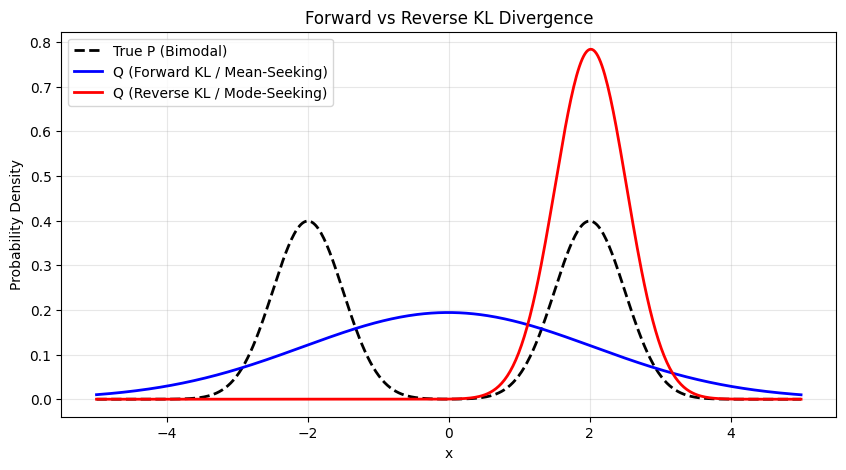

In [8]:
import matplotlib.pyplot as plt

params_fwd, params_rev = training_loop()

x = jnp.linspace(-5, 5, 500)

# JAX arrays play nicely with matplotlib natively
y_p = jnp.exp(p_log_prob(x))
y_q_fwd = jnp.exp(q_log_prob(params_fwd, x))
y_q_rev = jnp.exp(q_log_prob(params_rev, x))

plt.figure(figsize=(10, 5))
plt.plot(x, y_p, label="True P (Bimodal)", color="black", linewidth=2, linestyle="--")
plt.plot(x, y_q_fwd, label="Q (Forward KL / Mean-Seeking)", color="blue", linewidth=2)
plt.plot(x, y_q_rev, label="Q (Reverse KL / Mode-Seeking)", color="red", linewidth=2)

plt.title("Forward vs Reverse KL Divergence")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final thoughts

Ok, so what have we done? We have started off with a model which is a Gaussian and tried to fit it to the bimodal Gaussian mixture. The single Gaussian will never be able to fit the bimodal Gaussian but depending on whether we use the forward KL or the reverse KL we get different behaviours. 

For forward KL, the final Gaussian model we get tries to cover all of the bimodal Gaussian mixture, as seen by the blue line over the black dashed bimodal mixture. This is why it is called mean seeking; it tries to cover all bases.

In contrast, reverse KL makes the final Gaussian model focus around one of the bimodal mixture's peaks, as seen by the red line over the mean 2 peak. This is why reverse KL is called mode seeking.

So which one is better? This depends on your use case. Concretely, let's consider the teacher $P$ and student $Q$ use case. If we want the student $Q$ to learn and cover $P$ as much as possible, forward KL is the correct choice. For example, if we want to distil the general knowledge of $P$ onto $Q$. However, if we want $Q$ to focus on the peak of $P$, the reverse KL is the loss function to use. This is particularly useful in reasoning such as mathematics. When solving an equation, there tends to be one correct answer, and we need to distil that particular reasoning path rather than the general knowledge.